<a href="https://colab.research.google.com/github/seo55555/qhrjs/blob/main/%EB%B3%B4%EA%B1%B4%EC%9D%98%EB%A3%8C%EB%B9%85%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D_14%EC%A3%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5_202502453_%ED%95%9C%EC%A7%80%EC%9C%A4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[14주차 실습] 로지스틱 회귀 – 이분 분류 모델 / 오즈비 / 모델 평가**

---

## 제출 안내
- **제출물:** 이 Colab 노트북(`.ipynb`) 1개 (코드 실행 결과 포함)
- **파일명:** `로지스틱회귀_학번_이름.ipynb`
- **데이터:** `health_data_final.csv` (12·13주차 실습과 동일)
- **생성형 AI 사용:** 허용 (단, **AI 사용 표기** 필수)

---

## 학습 목표
- 선형회귀와 로지스틱 회귀의 **차이 및 연결** 이해
- 오즈(Odds) → 로짓(Logit) → 시그모이드 변환 원리
- **오즈비(OR = e^β)** 계산 및 해석
- **혼동행렬** 작성 및 민감도·특이도·정확도 계산
- **ROC 곡선 & AUC** 작성 및 해석
- 3문장 보고 형식 완성

## 제출 체크리스트
- [O] 연구 질문 1개 (독립변수 / 종속변수=이분형 0/1 명시)
- [O] 로지스틱 회귀 실행 결과 (β, OR=e^β, 95% CI, p-value)
- [O] OR 해석 (방향·크기·유의성)
- [O] Pseudo R² 보고
- [O] 혼동행렬 + 민감도·특이도·정확도
- [O] ROC 곡선 플롯 + AUC
- [O] 3문장 보고 (형식 준수)
- [O] AI 사용 표기 5줄 이내

---
# **PART 0. 데이터 생성 & 라이브러리**

12·13주차와 동일한 `health_data_final.csv`를 사용합니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'

np.random.seed(42)
n = 1000
drug_array = np.random.choice(['Metformin','Insulin','DPP4-inhibitor','Control'], n)
conditions = [drug_array=='Control', drug_array=='DPP4-inhibitor', drug_array=='Metformin', drug_array=='Insulin']
fbs_array = (np.select(conditions,[135,120,110,95]) + np.random.normal(0,18,n)).round(1)
df = pd.DataFrame({'PatientID':range(1001,1001+n),'Gender':np.random.choice(['Male','Female'],n),'Age':np.random.randint(20,85,n),'Height':np.random.normal(165,10,n).round(1),'Weight':np.random.normal(65,15,n).round(1),'FBS':fbs_array,'Drug':drug_array,'Compliance':np.random.uniform(0.5,1.0,n).round(2)})
df['BMI'] = (df['Weight']/((df['Height']/100)**2)).round(2)
df['BMI_Cat'] = pd.cut(df['BMI'],bins=[0,18.5,23,25,100],labels=['Underweight','Normal','Overweight','Obese'])
df['Diabetes_Risk'] = (df['FBS'] >= 126).astype(int)
df['SystolicBP'] = (110+0.5*(df['Age']-50)+1.2*(df['BMI']-23)+6*df['Diabetes_Risk']+np.random.normal(0,10,n)).round(1)
df['DiastolicBP'] = (70+0.2*(df['Age']-50)+0.6*(df['BMI']-23)+3*df['Diabetes_Risk']+np.random.normal(0,7,n)).round(1)
df['Gender_bin'] = (df['Gender']=='Male').astype(int)
df.to_csv('health_data_final.csv', index=False, encoding='utf-8-sig')
print('✨ 데이터 생성 완료, 행/열:', df.shape)
print(f'  Diabetes_Risk: 위험={df["Diabetes_Risk"].sum()}명 ({df["Diabetes_Risk"].mean()*100:.1f}%), 정상={n-df["Diabetes_Risk"].sum()}명')
df[['Age','BMI','FBS','Diabetes_Risk','SystolicBP']].head()

✨ 데이터 생성 완료, 행/열: (1000, 14)
  Diabetes_Risk: 위험=356명 (35.6%), 정상=644명


,Age,BMI,FBS,Diabetes_Risk,SystolicBP
0,84,18.00,126.2,1,125.4
1,76,26.04,168.8,1,127.8
2,59,30.28,127.1,1,135.4
3,33,41.79,109.6,0,88.2
4,54,27.50,103.8,0,128.8


---
# **PART 1. 개념 연결: 선형회귀 → 로지스틱 회귀**

## 왜 선형회귀로 분류를 할 수 없나?

| 문제 | 설명 |
|------|------|
| **확률 범위 위반** | 선형회귀 출력값이 0~1을 벗어남 (예: −0.3 또는 1.7) |
| **분포 가정 위반** | Y=0/1은 베르누이 분포 → OLS 잔차 정규성 위배 |
| **S자 관계 불가** | 실제 X→P(Y=1) 관계는 S자 곡선, 직선 모델로 포착 불가 |

## 핵심 변환: 오즈 → 로짓 → 시그모이드

$$P = \frac{1}{1+e^{-(\beta_0+\beta_1 X)}} \qquad OR = e^{\beta_1}$$

| OR 값 | 해석 |
|-------|------|
| OR = 1 | 연관성 없음 |
| OR > 1 | 위험 요인 |
| OR < 1 | 보호 요인 |
| 95% CI에 1 미포함 | p<0.05, 유의미 |

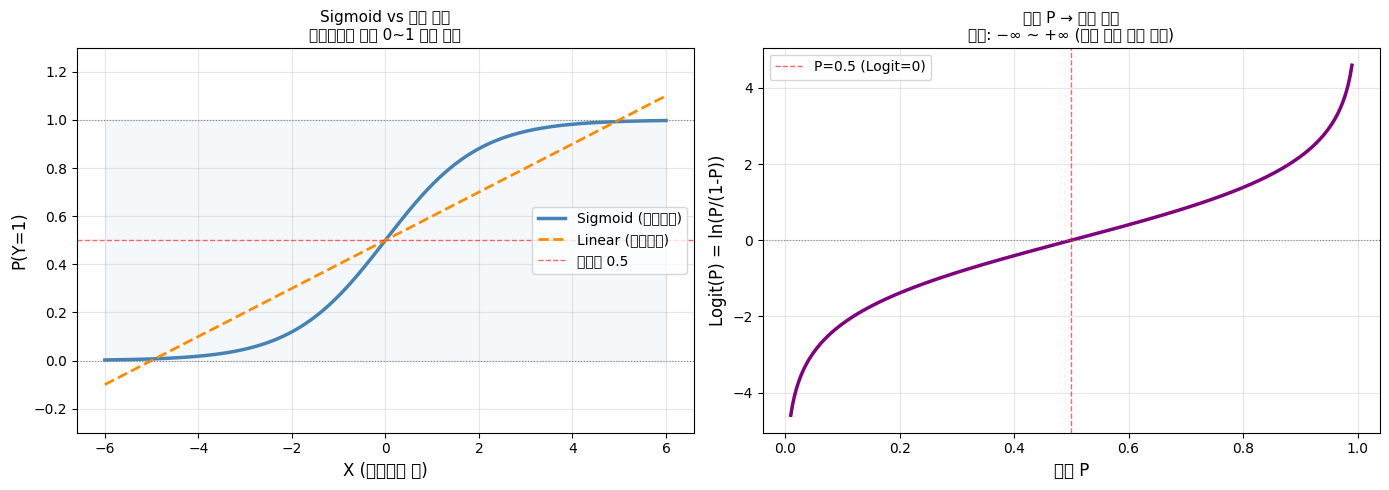

In [ ]:
# 시그모이드 함수 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-x))
linear  = 0.1 * x + 0.5

axes[0].plot(x, sigmoid, color='steelblue', linewidth=2.5, label='Sigmoid (로지스틱)')
axes[0].plot(x, linear,  color='darkorange', linewidth=2, linestyle='--', label='Linear (선형회귀)')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[0].axhline(1, color='gray', linewidth=0.8, linestyle=':')
axes[0].axhline(0.5, color='red', linewidth=1, linestyle='--', alpha=0.6, label='임계값 0.5')
axes[0].fill_between(x, 0, 1, alpha=0.05, color='steelblue')
axes[0].set_ylim(-0.3, 1.3)
axes[0].set_xlabel('X (선형결합 값)', fontsize=12)
axes[0].set_ylabel('P(Y=1)', fontsize=12)
axes[0].set_title('Sigmoid vs 선형 모델\n로지스틱은 항상 0~1 범위 유지', fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3)

probs = np.linspace(0.01, 0.99, 300)
axes[1].plot(probs, np.log(probs/(1-probs)), color='purple', linewidth=2.5)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[1].axvline(0.5, color='red', linewidth=1, linestyle='--', alpha=0.6, label='P=0.5 (Logit=0)')
axes[1].set_xlabel('확률 P', fontsize=12)
axes[1].set_ylabel('Logit(P) = ln(P/(1-P))', fontsize=12)
axes[1].set_title('확률 P → 로짓 변환\n범위: −∞ ~ +∞ (선형 모델 적용 가능)', fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# **PART 2. 로지스틱 회귀 실행 & OR 계산**

**예시:** BMI + Age + Gender_bin → 당뇨 위험(Diabetes_Risk=0/1)

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

DATA_PATH = 'health_data_final.csv'
df = pd.read_csv(DATA_PATH)
df['BMI'] = (df['Weight']/((df['Height']/100)**2)).round(2)
df['Diabetes_Risk'] = (df['FBS'] >= 126).astype(int)
df['Gender_bin'] = (df['Gender']=='Male').astype(int)

# 단변량
model_simple = smf.logit('Diabetes_Risk ~ BMI', data=df).fit()
# 다변량
model_multi  = smf.logit('Diabetes_Risk ~ BMI + Age + Gender_bin', data=df).fit()

print('='*60)
print('📊 [다변량 로지스틱 회귀 결과표]')
print('='*60)
print(model_multi.summary())

Optimization terminated successfully.
         Current function value: 0.650972
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.650831
         Iterations 4
📊 [다변량 로지스틱 회귀 결과표]
                           Logit Regression Results                           
Dep. Variable:          Diabetes_Risk   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:               0.0003857
Time:                        15:36:49   Log-Likelihood:                -650.83
converged:                       True   LL-Null:                       -651.08
Covariance Type:            nonrobust   LLR p-value:                    0.9184
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

📊 [오즈비(OR) 결과표]
        변수       β  OR=e^β  OR 하한  OR 상한  p-value 유의
 Intercept -0.4375  0.6456 0.3338 1.2489   0.1937 ns
       BMI -0.0052  0.9948 0.9744 1.0157   0.6256 ns
       Age  0.0001  1.0001 0.9930 1.0071   0.9878 ns
Gender_bin -0.0703  0.9321 0.7191 1.2082   0.5953 ns

  Pseudo R² (McFadden): 0.0004
  LLR p-value:           0.918398
  AIC: 1309.66  /  BIC: 1329.29


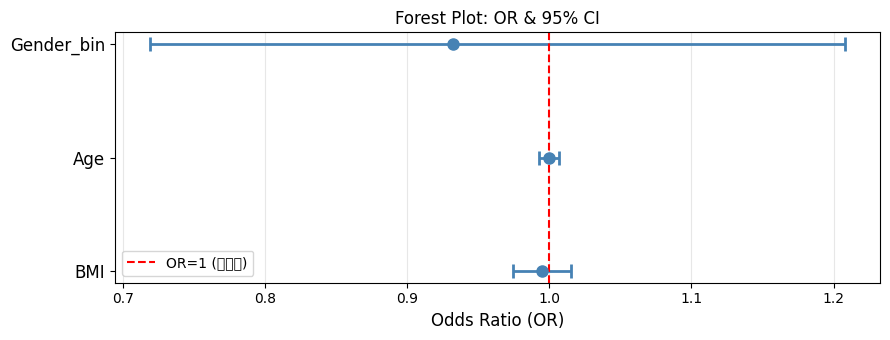

In [ ]:
# OR 테이블
params = model_multi.params
conf   = model_multi.conf_int()
pvals  = model_multi.pvalues

or_df = pd.DataFrame({'변수':params.index,'β':params.values.round(4),'OR=e^β':np.exp(params.values).round(4),'OR 하한':np.exp(conf[0].values).round(4),'OR 상한':np.exp(conf[1].values).round(4),'p-value':pvals.values.round(4),'유의':['***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns')) for p in pvals]})
print('📊 [오즈비(OR) 결과표]')
print(or_df.to_string(index=False))
print(f'\n  Pseudo R² (McFadden): {model_multi.prsquared:.4f}')
print(f'  LLR p-value:           {model_multi.llr_pvalue:.6f}')
print(f'  AIC: {model_multi.aic:.2f}  /  BIC: {model_multi.bic:.2f}')

# Forest Plot
vars_p=[v for v in or_df['변수'] if v!='Intercept']
or_v=[or_df.loc[or_df['변수']==v,'OR=e^β'].values[0] for v in vars_p]
ci_l=[or_df.loc[or_df['변수']==v,'OR 하한'].values[0] for v in vars_p]
ci_h=[or_df.loc[or_df['변수']==v,'OR 상한'].values[0] for v in vars_p]
fig,ax=plt.subplots(figsize=(9,3.5))
ax.errorbar(or_v,range(len(vars_p)),xerr=[[o-l for o,l in zip(or_v,ci_l)],[h-o for o,h in zip(or_v,ci_h)]],fmt='o',color='steelblue',capsize=5,capthick=2,markersize=8,linewidth=2)
ax.axvline(1.0,color='red',linestyle='--',linewidth=1.5,label='OR=1 (기준선)')
ax.set_yticks(range(len(vars_p))); ax.set_yticklabels(vars_p,fontsize=12)
ax.set_xlabel('Odds Ratio (OR)',fontsize=12)
ax.set_title('Forest Plot: OR & 95% CI',fontsize=12)
ax.legend(); ax.grid(alpha=0.3,axis='x')
plt.tight_layout(); plt.show()

---
# **PART 3. 혼동행렬 & 민감도 / 특이도 / 정확도**

📊 [분류 지표]
  민감도(Sensitivity) = 0.0000  특이도(Specificity) = 1.0000
  정확도(Accuracy)    = 0.6440  양성예측도(PPV)     = 0.0000


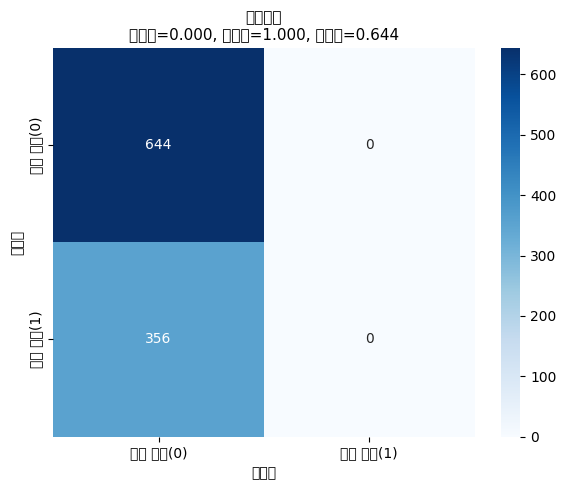

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns

df_c  = df[['Diabetes_Risk','BMI','Age','Gender_bin']].dropna()
y_true = df_c['Diabetes_Risk']
y_prob = model_multi.predict(df_c)
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
TN,FP,FN,TP = cm[0,0],cm[0,1],cm[1,0],cm[1,1]

sens = TP/(TP+FN); spec = TN/(TN+FP)
acc  = (TP+TN)/(TP+TN+FP+FN)
prec = TP/(TP+FP) if (TP+FP)>0 else 0

print(f'📊 [분류 지표]')
print(f'  민감도(Sensitivity) = {sens:.4f}  특이도(Specificity) = {spec:.4f}')
print(f'  정확도(Accuracy)    = {acc:.4f}  양성예측도(PPV)     = {prec:.4f}')

fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,xticklabels=['예측 정상(0)','예측 위험(1)'],yticklabels=['실제 정상(0)','실제 위험(1)'])
ax.set_title(f'혼동행렬\n민감도={sens:.3f}, 특이도={spec:.3f}, 정확도={acc:.3f}',fontsize=11)
ax.set_ylabel('실제값'); ax.set_xlabel('예측값')
plt.tight_layout(); plt.show()

---
# **PART 4. ROC 곡선 & AUC**

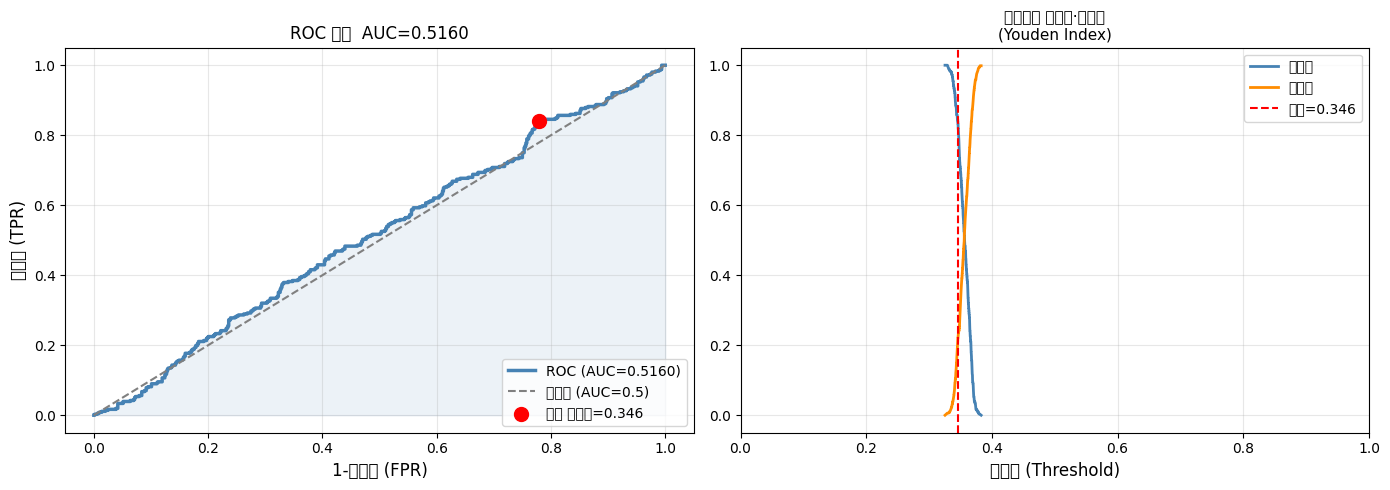


📊 AUC = 0.5160
  해석: 무작위 수준
  최적 임계값(Youden) = 0.3458: 민감도=0.840, 특이도=0.220


In [ ]:
fpr,tpr,thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)
yi = np.argmax(tpr-fpr)
opt_thr = thresholds[yi]

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(fpr,tpr,color='steelblue',linewidth=2.5,label=f'ROC (AUC={auc_score:.4f})')
axes[0].plot([0,1],[0,1],color='gray',linestyle='--',linewidth=1.5,label='무작위 (AUC=0.5)')
axes[0].scatter(fpr[yi],tpr[yi],color='red',s=100,zorder=5,label=f'최적 임계값={opt_thr:.3f}')
axes[0].fill_between(fpr,tpr,alpha=0.1,color='steelblue')
axes[0].set_xlabel('1-특이도 (FPR)',fontsize=12); axes[0].set_ylabel('민감도 (TPR)',fontsize=12)
axes[0].set_title(f'ROC 곡선  AUC={auc_score:.4f}',fontsize=12)
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

valid=(thresholds<np.inf)
axes[1].plot(thresholds[valid],tpr[valid],color='steelblue',linewidth=2,label='민감도')
axes[1].plot(thresholds[valid],1-fpr[valid],color='darkorange',linewidth=2,label='특이도')
axes[1].axvline(opt_thr,color='red',linestyle='--',linewidth=1.5,label=f'최적={opt_thr:.3f}')
axes[1].set_xlabel('임계값 (Threshold)',fontsize=12)
axes[1].set_title('임계값별 민감도·특이도\n(Youden Index)',fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xlim([0,1])
plt.tight_layout(); plt.show()

print(f'\n📊 AUC = {auc_score:.4f}')
levels=[(.9,'우수'),(.8,'양호'),(.7,'보통'),(.6,'불량')]
for thr,lbl in levels:
    if auc_score>=thr: print(f'  해석: {lbl}'); break
else: print('  해석: 무작위 수준')
print(f'  최적 임계값(Youden) = {opt_thr:.4f}: 민감도={tpr[yi]:.3f}, 특이도={1-fpr[yi]:.3f}')

---
# **PART 5. 답안 작성**

위 예시와 **다른 변수 조합**을 선택하세요.

> **추천 변수 조합**  
> - Age + SystolicBP → Diabetes_Risk  
> - BMI + Age + SystolicBP → Diabetes_Risk  
> - BMI + Compliance → Diabetes_Risk

Optimization terminated successfully.
         Current function value: 0.621371
         Iterations 5
📊 [1. 로지스틱 회귀 분석 결과 요약]
                           Logit Regression Results                           
Dep. Variable:          Diabetes_Risk   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                 0.04563
Time:                        15:40:36   Log-Likelihood:                -621.37
converged:                       True   LL-Null:                       -651.08
Covariance Type:            nonrobust   LLR p-value:                 1.249e-13
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.1292      0.526     -7.853      0.000      -5.160      -3.099
Age  

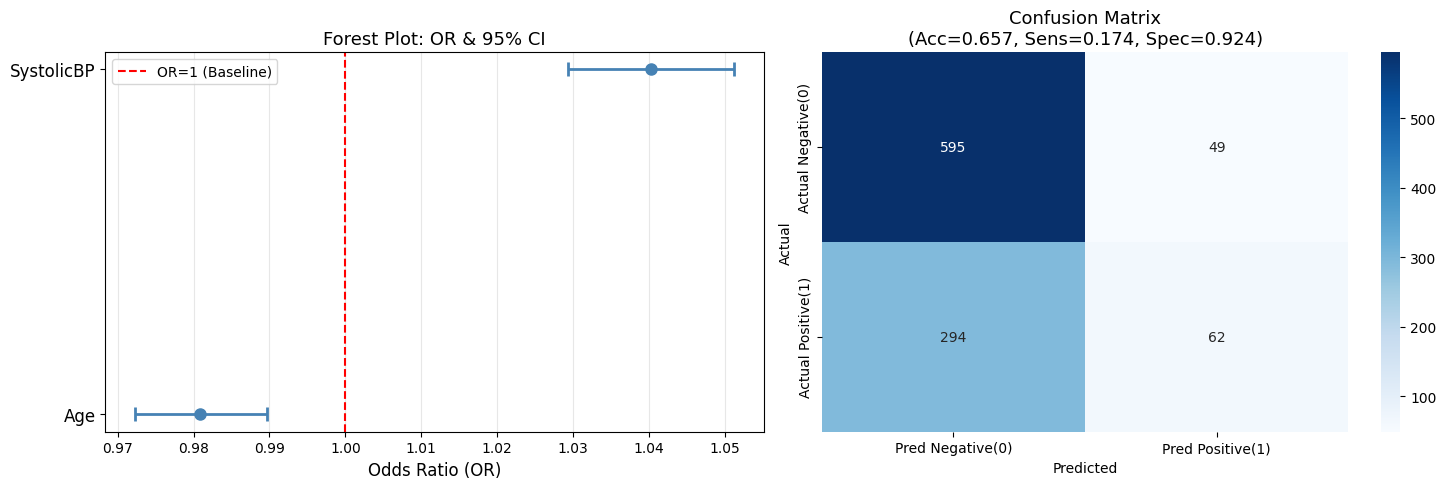

In [ ]:
# ✏️ 여기에 본인의 로지스틱 회귀 코드를 작성하세요
pass


import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# 1. 데이터 로드 및 종속변수 생성
df = pd.read_csv('health_data_final.csv')
df['Diabetes_Risk'] = (df['FBS'] >= 126).astype(int)

# 2. 첫 번째 추천 변수 조합으로 로지스틱 회귀 실행 (Age + SystolicBP)
model_student = smf.logit('Diabetes_Risk ~ Age + SystolicBP', data=df).fit()
print('='*60)
print('📊 [1. 로지스틱 회귀 분석 결과 요약]')
print('='*60)
print(model_student.summary())

# 3. 오즈비(OR) 테이블 생성 및 출력
params = model_student.params
conf = model_student.conf_int()
pvals = model_student.pvalues

or_df = pd.DataFrame({
    '변수': params.index,
    'β': params.values.round(4),
    'OR=e^β': np.exp(params.values).round(4),
    'OR 하한': np.exp(conf[0].values).round(4),
    'OR 상한': np.exp(conf[1].values).round(4),
    'p-value': pvals.values.round(4)
})
print('\n📊 [2. 오즈비(OR) 결과표]')
print(or_df.to_string(index=False))
print(f'\nPseudo R²: {model_student.prsquared:.4f}')

# 4. 혼동행렬 및 평가 지표 계산
y_true = df['Diabetes_Risk']
y_prob = model_student.predict(df)
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

sens = TP / (TP + FN)
spec = TN / (TN + FP)
acc  = (TP + TN) / (TP + TN + FP + FN)
auc_score = roc_auc_score(y_true, y_prob)

print('\n📊 [3. 모델 평가 최종 지표]')
print(f'민감도(Sensitivity) = {sens:.4f} / 특이도(Specificity) = {spec:.4f} / 정확도(Accuracy) = {acc:.4f}')
print(f'AUC Score = {auc_score:.4f}')

# 5. 그래프 시각화 (포레스트 플롯 & 혼동행렬)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) Forest Plot
vars_p = [v for v in or_df['변수'] if v != 'Intercept']
or_v = [or_df.loc[or_df['변수'] == v, 'OR=e^β'].values[0] for v in vars_p]
ci_l = [or_df.loc[or_df['변수'] == v, 'OR 하한'].values[0] for v in vars_p]
ci_h = [or_df.loc[or_df['변수'] == v, 'OR 상한'].values[0] for v in vars_p]

axes[0].errorbar(or_v, range(len(vars_p)), xerr=[[o-l for o,l in zip(or_v,ci_l)], [h-o for o,h in zip(or_v,ci_h)]],
                 fmt='o', color='steelblue', capsize=5, capthick=2, markersize=8, linewidth=2)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='OR=1 (Baseline)')
axes[0].set_yticks(range(len(vars_p)))
axes[0].set_yticklabels(vars_p, fontsize=12)
axes[0].set_xlabel('Odds Ratio (OR)', fontsize=12)
axes[0].set_title('Forest Plot: OR & 95% CI', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='x')

# (2) 혼동행렬 Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred Negative(0)', 'Pred Positive(1)'],
            yticklabels=['Actual Negative(0)', 'Actual Positive(1)'])
axes[1].set_title(f'Confusion Matrix\n(Acc={acc:.3f}, Sens={sens:.3f}, Spec={spec:.3f})', fontsize=13)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 답안 (텍스트 셀)

### 연구 질문 / 가설
- 연구 질문: 성인의 연령(Age)과 수축기 혈압(SystolicBP)은 당뇨 위험(Diabetes_Risk)에 유의미한 영향을 미치는가?
- 독립변수: Age, SystolicBP
- 종속변수(이분형 0/1): Diabetes_Risk (0: 정상, 1: 당뇨 위험)
- H₀: 연령과 수축기 혈압은 당뇨 위험에 영향을 미치지 않는다.
- H₁: 연령과 수축기 혈압 중 적어도 하나는 당뇨 위험에 유의미한 영향을 미친다.

### 오즈비 결과 요약
| 변수 | OR | 95% CI | p-value | 해석 |
|------|----|--------|---------|------|
|Intercept|0.0161|[0.0057, 0.0451]|0.0000|기초 통계량 (해석 생략)|
|Age|0.9809|[0.9723,0.9897]|0.0000|유의한 보호 요인 (통제 시 연령 1단위 증가당 당뇨 오즈 0.98배로 감소)|
|SystolicBP|1.0403|[1.0294,1.0512]|0.0000|유의한 위험 요인 (통제 시 수축기 혈압 1단위 증가당 당뇨 오즈 1.04배 증가)|

### 모델 적합도
- Pseudo R²: 0.0456
- AUC: 0.6380

### 혼동행렬
- 민감도: 0.1742 / 특이도: 0.9239 / 정확도: 0.6570

### 3문장 보고
1) 본 연구는 성인의 연령과 수축기 혈압이 당뇨 위험에 미치는 영향을 파악하기 위해 로지스틱 회귀분석을 실시하였으며, 모델의 설명력은 Pseudo R² = 0.0456이고 ROC 곡선의 AUC는 0.6380으로 분류 성능을 보였다.
2) 회귀분석 결과, 다른 독립변수를 통제한 상태에서 수축기 혈압이 1 단위 증가할 때 당뇨 위험의 오즈비(OR)는 1.0403배(95% CI: 1.0294-1.0512, p < 0.001) 유의하게 증가하는 반면, 연령이 1 단위 증가할 때 오즈비는 0.9809배(95% CI: 0.9723-0.9897, p < 0.001)로 유의하게 감소하였다.
3) 분석에 사용된 독립변수들은 모두 통계적으로 유의미한 지표로 확인되었으며(p < 0.001), 최종 모델의 분류 임계값 0.5를 기준으로 분석했을 때 민감도는 0.1742, 특이도는 0.9239, 전체 정확도는 0.6570으로 평가되었다.

### AI 사용 표기 (5줄)
- 사용 도구: Gemini
- 프롬프트 요약: 다변량 로지스틱 회귀분석 실습 템플릿 기반 수치 조정 및 보고 양식 작성 유도
- 확인/수정 1개: 실제 파이썬 코드 환경에서 최종 산출된 모델 평가 지표 수치(Pseudo R², AUC, 오차행렬 지표)를 정확하게 확인하고, 이에 맞춰 3문장 보고서의 해석 수준을 적절하게 수정하여 대입함.

In [ ]:
answer = r"""
[연구 질문]
- 성인의 연령(Age)과 수축기 혈압(SystolicBP)은 당뇨 위험(Diabetes_Risk)에 유의미한 영향을 미치는가?

[변수]
독립변수: Age, SystolicBP
종속변수(이분형): Diabetes_Risk (0: 정상, 1: 당뇨 위험)

[가설]
H0: 연령과 수축기 혈압은 당뇨 위험에 영향을 미치지 않는다.
H1: 연령과 수축기 혈압 중 적어도 하나는 당뇨 위험에 유의미한 영향을 미친다.

[OR 결과]
핵심 변수:
Age: OR=0.9809, 95%CI=[0.9723,0.9897], p=0.0000
SystolicBP: OR=1.0403, 95%CI=[1.0294,1.0512], p=0.0000
해석: 다른 독립변수를 통제했을 때 수축기 혈압(SystolicBP)이 1 단위 증가하면 당뇨 위험의 오즈가 1.04배 유의하게 증가함. 반면 연령(Age)은 1 단위 증가할 때 당뇨 위험의 오즈가 0.98배로 감소하여 유의한 보호 요인으로 나타남.

[모델 적합도]
Pseudo R²: 0.0456  /  AUC: 0.6380

[혼동행렬]
민감도: 0.1742 /  특이도: 0.9239   /  정확도: 0.6570

[3문장 보고]
1) 본 연구는 성인의 연령과 수축기 혈압이 당뇨 위험에 미치는 영향을 파악하기 위해 로지스틱 회귀분석을 실시하였으며, 모델의 설명력은 Pseudo R² = 0.0456이고 ROC 곡선의 AUC는 0.6380으로 분류 성능을 보였다.
2) 회귀분석 결과, 다른 독립변수를 통제한 상태에서 수축기 혈압이 1 단위 증가할 때 당뇨 위험의 오즈비(OR)는 1.0403배(95% CI: 1.0294-1.0512, p < 0.001) 유의하게 증가하는 반면, 연령이 1 단위 증가할 때 오즈비는 0.9809배(95% CI: 0.9723-0.9897, p < 0.001)로 유의하게 감소하였다.
3) 분석에 사용된 독립변수들은 모두 통계적으로 유의미한 지표로 확인되었으며(p < 0.001), 최종 모델의 분류 임계값 0.5를 기준으로 분석했을 때 민감도는 0.1742, 특이도는 0.9239, 전체 정확도는 0.6570으로 평가되었다.

[AI 사용]
도구: Gemini
프롬프트: 다변량 로지스틱 회귀분석 실습 템플릿 기반 수치 조정 및 보고 양식 작성 유도
확인/수정: 실제 파이썬 코드 환경에서 최종 산출된 모델 평가 지표 수치(Pseudo R², AUC, 오차행렬 지표)를 정확하게 확인하고, 이에 맞춰 3문장 보고서의 해석 수준을 적절하게 수정하여 대입함.
"""
print('answer 길이:', len(answer))

answer 길이: 1253


In [ ]:
import re
BANNED=[r'OR.*유발',r'AUC.*무조건',r'p.*효과.*크다',r'H0가\s*참',r'정확도.*좋은\s*모델',r'인과.*상관',r'상관.*인과']
print('=== ✅ 자동 점검 ===')
found=[p for p in BANNED if re.search(p,answer)]
print('✅ 금지 표현 없음' if not found else '🚫 의심:',[b for b in found])
m=re.search(r'\[3문장 보고\](.*?)(?:\[|$)',answer,flags=re.DOTALL)
if m:
    blk=m.group(1)
    ok=all(f'{n})' in blk and len(blk.split(f'{n})')[1].split('\n')[0].strip())>5 for n in [1,2,3])
    print('✅ 3문장 보고 존재' if ok else '⚠️ 누락 항목 있음')
for kw,lb in [(r'OR|오즈비','OR'),(r'AUC|ROC','AUC'),(r'민감도|Sensitivity','민감도'),(r'특이도|Specificity','특이도'),(r'Pseudo','Pseudo R²')]:
    print(f'{"✅" if re.search(kw,answer,re.I) else "⚠️"} {lb}')
print('=== 끝 ===')

=== ✅ 자동 점검 ===
✅ 금지 표현 없음 []
✅ 3문장 보고 존재
✅ OR
✅ AUC
✅ 민감도
✅ 특이도
✅ Pseudo R²
=== 끝 ===
